# HDB Resale Price Regression — Notebook 12: Model Diagnostics

Experts flagged several diagnostic checks for Model 10 (R-squared 0.90, 50,718 transactions). This notebook validates the model against standard regression assumptions:

1. **Residual normality** — Q-Q plots and histograms (are the residuals well-behaved?)
2. **Influential points** — Cook's distance (is any single transaction pulling the fit?)
3. **Multicollinearity** — VIF (are town dummies and distance variables double-counting?)
4. **Model selection** — AIC/BIC (is Model 10 the right size, or is it over/under-parameterised?)
5. **Coefficient stability** — do the key findings survive across specifications?

Raw-price Model 10 is the primary subject (the reporting model). Log model comparisons are shown where relevant.

In [1]:
%load_ext rpy2.ipython
import warnings
warnings.filterwarnings('ignore')

Error importing in API mode: ImportError("dlopen(/Users/wongpeiting/.pyenv/versions/3.13.9/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): Library not loaded: /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib\n  Referenced from: <B96A8100-FA7A-3EFC-8726-931D26646DE6> /Users/wongpeiting/.pyenv/versions/3.13.9/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so\n  Reason: tried: '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file)")


Trying to import in ABI mode.


In [2]:
%%R
library(tidyverse)
library(sandwich)
library(lmtest)
library(car)
library(ggplot2)

df <- read_csv('data/hdb_analysis.csv', show_col_types = FALSE)
df$remaining_lease_sq <- df$remaining_lease_years^2
df$month_factor <- factor(format(df$month, '%Y-%m'))
df$ln_price <- log(df$resale_price)

# Raw-price Model 10 (from Notebook 6)
model10 <- lm(resale_price ~ town + flat_type + floor_area_sqm + storey_mid +
              remaining_lease_years + remaining_lease_sq +
              flat_model_grouped +
              dist_cbd_km + mrt_dist_m + hawker_dist_m +
              popular_school_dist_m +
              park_dist_m + hospital_dist_m +
              columbarium_dist_m + temple_dist_m +
              coast_dist_m +
              num_eights_tail +
              price_has_168 +
              block_has_4 +
              cny_month +
              month_factor,
            data = df)

# Log model (from Notebook 11)
model_log <- lm(ln_price ~ town + flat_type + floor_area_sqm + storey_mid +
              remaining_lease_years + remaining_lease_sq +
              flat_model_grouped +
              dist_cbd_km + mrt_dist_m + hawker_dist_m +
              popular_school_dist_m +
              park_dist_m + hospital_dist_m +
              columbarium_dist_m + temple_dist_m +
              coast_dist_m +
              num_eights_tail +
              price_has_168 +
              block_has_4 +
              cny_month +
              month_factor,
            data = df)

cat(sprintf('Raw Model 10:  R\u00b2 = %.4f, %d parameters\n',
    summary(model10)$r.squared, length(coef(model10))))
cat(sprintf('Log Model 10:  R\u00b2 = %.4f, %d parameters\n',
    summary(model_log)$r.squared, length(coef(model_log))))
cat(sprintf('Observations:  %s\n', format(nrow(df), big.mark = ',')))

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.2.1     


── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


Raw Model 10:  R² = 0.9023, 87 parameters


Log Model 10:  R² = 0.9373, 87 parameters


Observations:  50,718


Loading required package: zoo

Attaching package: ‘zoo’

The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric

Loading required package: carData

Attaching package: ‘car’

The following object is masked from ‘package:dplyr’:

    recode

The following object is masked from ‘package:purrr’:

    some



## 1. Residual normality

OLS assumes residuals are normally distributed. With n = 50,718 and robust standard errors, mild non-normality won't bias the coefficients — but heavy tails mean outliers are pulling the fit harder than they should. The log transform should improve this.

**How to read Q-Q plots:** Points follow the diagonal line = normal. Points curving away at the ends = heavy tails (outliers more extreme than a normal distribution would produce).

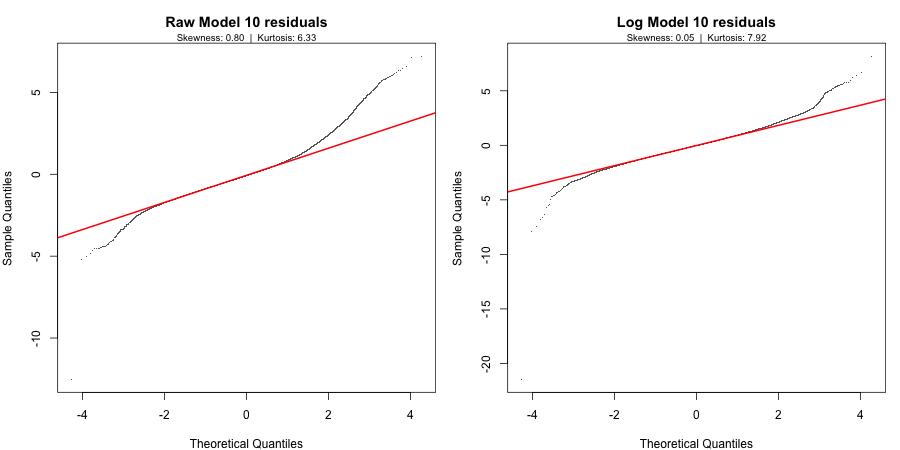

In [3]:
%%R -w 900 -h 450
library(moments)

par(mfrow = c(1, 2), mar = c(4, 4, 3, 1))

# Raw model Q-Q
raw_resid <- rstandard(model10)
qqnorm(raw_resid, main = 'Raw Model 10 residuals',
       pch = '.', col = 'grey40', cex = 0.8)
qqline(raw_resid, col = 'red', lwd = 2)
mtext(sprintf('Skewness: %.2f  |  Kurtosis: %.2f',
    skewness(resid(model10)), kurtosis(resid(model10))),
    side = 3, line = 0, cex = 0.8)

# Log model Q-Q
log_resid <- rstandard(model_log)
qqnorm(log_resid, main = 'Log Model 10 residuals',
       pch = '.', col = 'grey40', cex = 0.8)
qqline(log_resid, col = 'red', lwd = 2)
mtext(sprintf('Skewness: %.2f  |  Kurtosis: %.2f',
    skewness(resid(model_log)), kurtosis(resid(model_log))),
    side = 3, line = 0, cex = 0.8)

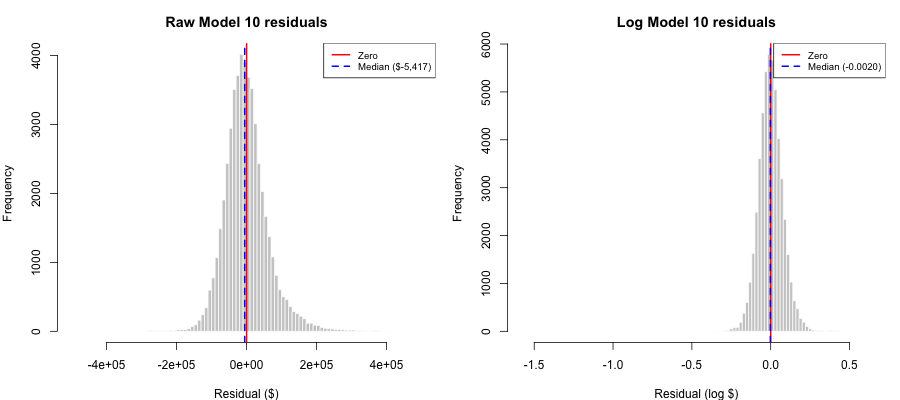

In [4]:
%%R -w 900 -h 400
par(mfrow = c(1, 2), mar = c(4, 4, 3, 1))

# Raw model residuals
hist(resid(model10), breaks = 100, col = 'grey80', border = 'white',
     main = 'Raw Model 10 residuals', xlab = 'Residual ($)',
     xlim = c(-500000, 500000))
abline(v = 0, col = 'red', lwd = 2)
abline(v = median(resid(model10)), col = 'blue', lwd = 2, lty = 2)
legend('topright', c('Zero', sprintf('Median ($%s)',
    format(round(median(resid(model10))), big.mark = ','))),
    col = c('red', 'blue'), lwd = 2, lty = c(1, 2), cex = 0.8)

# Log model residuals
hist(resid(model_log), breaks = 100, col = 'grey80', border = 'white',
     main = 'Log Model 10 residuals', xlab = 'Residual (log $)')
abline(v = 0, col = 'red', lwd = 2)
abline(v = median(resid(model_log)), col = 'blue', lwd = 2, lty = 2)
legend('topright', c('Zero', sprintf('Median (%.4f)',
    median(resid(model_log)))),
    col = c('red', 'blue'), lwd = 2, lty = c(1, 2), cex = 0.8)

### Interpretation

The raw model's Q-Q plot shows a classic heavy-tailed pattern: the left tail curves sharply below the diagonal (the model underestimates some cheap flats by a lot) and the right tail curves sharply above it (the model underestimates some expensive flats by even more). The skewness of 0.80 confirms a right-leaning residual distribution — the worst mis-predictions are concentrated among high-end transactions where the raw-dollar scale amplifies errors. The histogram makes this visible: the bulk of residuals sit close to zero, but there's a long right shoulder with transactions the model undervalues by $200,000 or more. The median residual of -$5,417 tells us the model very slightly systematically overpredicts the typical flat, though this is small relative to the ~$500K median price.

The log model largely fixes the skewness problem — skewness drops from 0.80 to 0.05, and the histogram is nearly symmetric around zero with a median residual of -0.002 (essentially nothing). This confirms that price relationships are multiplicative rather than additive: a 5% premium for a top floor is more natural than a fixed-dollar premium. However, kurtosis — a measure of how fat the tails are relative to a bell curve, where 3.0 is normal — actually worsens slightly, from 6.33 in the raw model to 7.92 in the log model. Both are far above normal. This means that while the log model stops the typical residual from leaning right, both models still have a cluster of extreme outliers (transactions the model gets very wrong) that sit much further from the prediction line than a normal distribution would produce.

For inference this matters less than it might seem. With n = 50,718, the central limit theorem ensures coefficient standard errors are reliable regardless of residual shape, and using HC3 robust standard errors (as in all previous notebooks) guards against the heteroscedasticity that often accompanies heavy tails. But the persistent kurtosis — even after the log transform — flags something real: there is a subset of transactions that no specification of this model fully explains. That is exactly the motivation for the L1/LAD regression in Notebook 13, which minimises absolute rather than squared errors and is inherently less sensitive to these extreme residuals pulling the fit.